<a href="https://colab.research.google.com/github/Thejuskuku/Feature-Engineering/blob/main/Facial_Pattern_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# pip install torch torchvision opencv-python pillow numpy scikit-learn

import os
import numpy as np
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [17]:
# ─────────────────────────────────────────────
# STEP 1: Download AT&T dataset & build folder structure
# ─────────────────────────────────────────────
from sklearn.datasets import fetch_olivetti_faces

print("Downloading AT&T faces...")
data = fetch_olivetti_faces(shuffle=False)

dataset_dir = Path("dataset")
for i, (img_arr, label) in enumerate(zip(data.images, data.target)):
    person_dir = dataset_dir / f"person_{label:02d}"
    person_dir.mkdir(parents=True, exist_ok=True)
    Image.fromarray((img_arr * 255).astype(np.uint8)).save(
        person_dir / f"img_{i:03d}.jpg"
    )
print(f"Saved {len(data.images)} images across {len(set(data.target))} people → ./dataset/")

Saved 400 images across 40 people → ./dataset/


In [18]:
# ─────────────────────────────────────────────
# STEP 2: Train
# ─────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nTraining on {device}...")
model = train("./dataset", epochs=20)   # saves facecnn.pt


Training on cpu...
Epoch   1/20  loss=3.6402  acc=9.0%
Epoch   2/20  loss=3.5396  acc=21.8%
Epoch   3/20  loss=3.4425  acc=47.2%
Epoch   4/20  loss=3.3516  acc=67.5%
Epoch   5/20  loss=3.2504  acc=85.2%
Epoch   6/20  loss=3.1608  acc=93.2%
Epoch   7/20  loss=3.0804  acc=97.2%
Epoch   8/20  loss=2.9950  acc=99.0%
Epoch   9/20  loss=2.9098  acc=99.0%
Epoch  10/20  loss=2.8408  acc=99.8%
Epoch  11/20  loss=2.7541  acc=99.5%
Epoch  12/20  loss=2.6731  acc=100.0%
Epoch  13/20  loss=2.5952  acc=100.0%
Epoch  14/20  loss=2.5238  acc=100.0%
Epoch  15/20  loss=2.4347  acc=100.0%
Epoch  16/20  loss=2.3609  acc=100.0%
Epoch  17/20  loss=2.2833  acc=100.0%
Epoch  18/20  loss=2.2117  acc=100.0%
Epoch  19/20  loss=2.1420  acc=100.0%
Epoch  20/20  loss=2.0669  acc=100.0%
Saved facecnn.pt


In [21]:
# ─────────────────────────────────────────────
# STEP 3: Build gallery (use first 8 images per person for gallery)
# ─────────────────────────────────────────────
import shutil

# Clear old gallery before rebuilding
gallery_dir = Path("gallery")
if gallery_dir.exists():
    shutil.rmtree(gallery_dir)

for person_dir in sorted(dataset_dir.iterdir()):
    if not person_dir.is_dir(): continue
    imgs = sorted(person_dir.glob("*.jpg"))[:8]
    out  = gallery_dir / person_dir.name
    out.mkdir(parents=True, exist_ok=True)
    for img in imgs:
        (out / img.name).symlink_to(img.resolve())

gallery = build_gallery(model, "./gallery", device)
print(f"\nGallery built: {len(gallery)} people")


Gallery built: 40 people


In [22]:
# ─────────────────────────────────────────────
# STEP 4: Test — use the 9th image of a person as query
# ─────────────────────────────────────────────
# Pick any image NOT in the gallery (9th image = index 8)
test_person = "person_03"                          # ← change to any person
query_path  = str(dataset_dir / test_person / f"img_{8+40*3:03d}.jpg")

# Simpler: just grab the 9th file directly
all_imgs    = sorted((dataset_dir / test_person).glob("*.jpg"))
query_path  = str(all_imgs[8])                     # 9th image (0-indexed)

print(f"\nQuery image : {query_path}")
name, sim = identify(model, gallery, query_path, threshold=0.5, device=device)
print(f"Predicted   : {name}  (similarity={sim:.1%})")
print(f"Expected    : {test_person}")
print(f"Correct     : {name == test_person}")


Query image : dataset/person_03/img_038.jpg
Predicted   : person_03  (similarity=97.9%)
Expected    : person_03
Correct     : True


In [23]:
# ─────────────────────────────────────────────
# STEP 5: Evaluate on all held-out (9th & 10th) images
# ─────────────────────────────────────────────
correct = total = 0
for person_dir in sorted(dataset_dir.iterdir()):
    if not person_dir.is_dir(): continue
    imgs = sorted(person_dir.glob("*.jpg"))
    for query in imgs[8:]:                         # images 9 & 10 not in gallery
        pred, sim = identify(model, gallery, str(query),
                             threshold=0.5, device=device)
        correct += (pred == person_dir.name)
        total   += 1

print(f"\nTest accuracy: {correct}/{total}  ({correct/total:.1%})")


Test accuracy: 80/80  (100.0%)


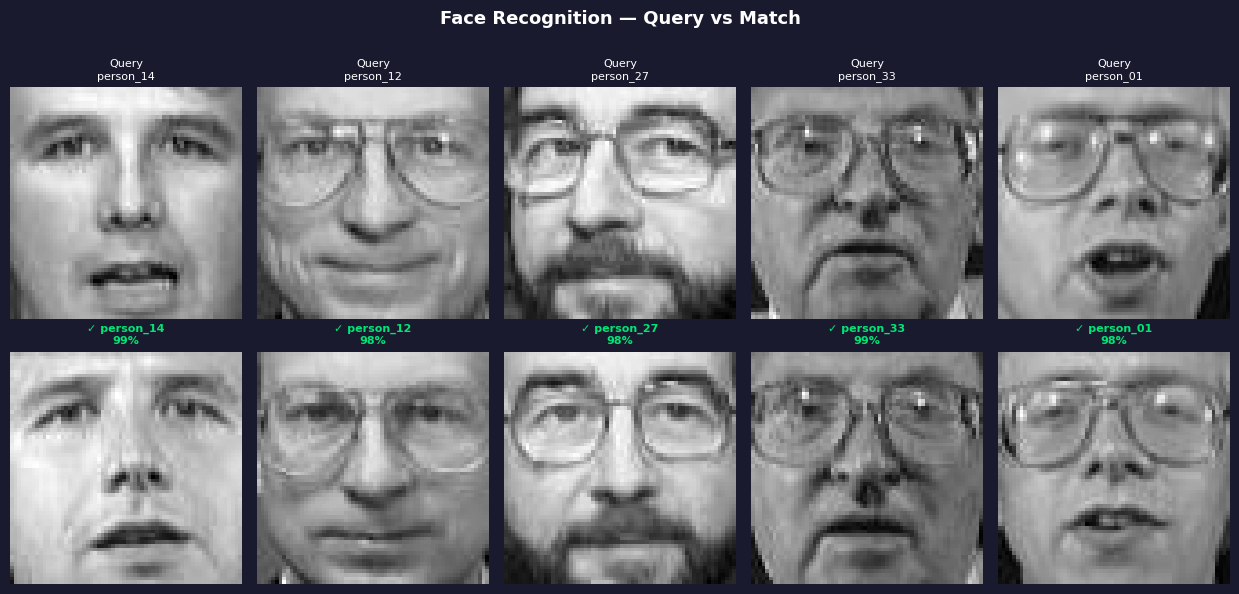

Saved → predictions.png


In [25]:
import matplotlib.pyplot as plt
import random

# ─────────────────────────────────────────────
# Visualize predictions vs actual
# ─────────────────────────────────────────────

def show_predictions(model, gallery, dataset_dir, device,
                     threshold=0.5, n=10, cols=5):
    """
    Shows a grid: each column = one test query.
    Top row    = query image  (what we gave the model)
    Bottom row = matched image from gallery (or red X if Unknown)
    Title color: green = correct, red = wrong
    """
    # Collect test images (9th & 10th per person)
    test_samples = []
    for person_dir in sorted(Path(dataset_dir).iterdir()):
        if not person_dir.is_dir(): continue
        imgs = sorted(person_dir.glob("*.jpg"))
        for img in imgs[8:]:
            test_samples.append((str(img), person_dir.name))

    # Pick n random samples
    samples = random.sample(test_samples, min(n, len(test_samples)))

    rows = 2
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, 6))
    fig.patch.set_facecolor("#1a1a2e")

    for col, (query_path, true_name) in enumerate(samples[:cols]):
        pred_name, sim = identify(model, gallery, query_path,
                                  threshold=threshold, device=device)
        correct = (pred_name == true_name)
        color   = "#00e676" if correct else "#ff1744"

        # ── Top row: query image ──
        ax_q = axes[0][col]
        ax_q.imshow(Image.open(query_path).convert("L"), cmap="gray")
        ax_q.set_title(f"Query\n{true_name}", color="white", fontsize=8)
        ax_q.axis("off")
        for spine in ax_q.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(3)
        ax_q.set_visible(True)

        # ── Bottom row: best gallery match ──
        ax_m = axes[1][col]
        if pred_name != "Unknown":
            # grab first image of matched person from gallery
            match_imgs = sorted(Path("gallery", pred_name).glob("*.jpg"))
            if match_imgs:
                ax_m.imshow(Image.open(match_imgs[0]).convert("L"), cmap="gray")
        else:
            # red X for unknown
            ax_m.set_facecolor("#2d0000")
            ax_m.text(0.5, 0.5, "✗\nUnknown",
                      ha="center", va="center", color="#ff1744",
                      fontsize=14, transform=ax_m.transAxes)

        label = f"{'✓' if correct else '✗'} {pred_name}\n{sim:.0%}"
        ax_m.set_title(label, color=color, fontsize=8, fontweight="bold")
        ax_m.axis("off")
        for spine in ax_m.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(3)

    # Row labels
    for row, label in enumerate(["Query", "Best match"]):
        axes[row][0].set_ylabel(label, color="white", fontsize=10,
                                labelpad=8, rotation=90)

    plt.suptitle("Face Recognition — Query vs Match",
                 color="white", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("predictions.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("Saved → predictions.png")


show_predictions(model, gallery, "./dataset", device, threshold=0.5, n=10, cols=5)